In [1]:
import torch
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# Set the device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print('device:', device)

device: mps


In [2]:
data = pd.read_csv('ready.csv').drop(columns = 'Unnamed: 0')
data['skew'] = data['OTMP_IV_mean'] - data['ATMC_IV_mean']
data['RI_spread'] = data['RVol_mean'] - data['IVol_mean']
data['CP_spread'] = data['CVol_mean'] - data['PVol_mean']

rank = data.groupby('year_month')['month_exret'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop = True)
data['month_exret_rank'] = rank
data['Top'] = data['month_exret_rank'].apply(lambda x: 1 if x == 4 else 0)
data['Bottom'] = data['month_exret_rank'].apply(lambda x: -1 if x == 0 else 0)
data['rank'] = data['Top'] + data['Bottom'] + 1 # 0:Bottom, 1:Middle, 2:Top
data.drop(columns = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean', 'PVol_mean', 'Top', 'Bottom', 'month_exret_rank'], inplace = True)

data_for_model = data[data['year_month']<'2018']

data

,year_month,CUSIP,chmom,dolvol,Idiovol,indmom,maxret,mom1m,mom12m,mvel1,retvol,month_ret,month_exret,skew,RI_spread,CP_spread,rank
0,1996-02,00154710,0.750294,0.305409,0.057332,0.621315,0.183914,0.553984,0.102541,0.006568,0.092558,0.043916,0.001597,0.032001,-0.041962,-0.069546,1
1,1996-02,00253A30,0.696998,0.165227,0.200661,0.758034,0.311045,0.828694,0.350606,0.001287,0.278413,-0.102041,-0.138899,-0.028164,-0.347774,-0.024086,0
2,1996-02,00282410,0.744484,0.717942,0.022986,0.974135,0.145965,0.564528,0.086431,0.262388,0.108329,-0.017646,-0.057942,0.030634,-0.016992,-0.006527,1
3,1996-02,00507V10,0.726639,0.256219,0.515400,0.619444,0.590862,0.744614,0.159775,0.000400,0.651524,0.092594,0.048120,-0.196498,-0.032070,0.069056,1
4,1996-02,00724F10,0.552887,0.802481,0.267530,0.619444,0.134598,0.136784,0.081697,0.023960,0.540971,-0.014709,-0.055008,-0.038984,0.023102,0.018708,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426313,2022-12,98980G10,0.289413,0.680486,0.021415,0.189687,0.067773,0.200569,0.045052,0.008343,0.111908,-0.161484,-0.350278,-0.032759,-0.184267,0.004251,0
426314,2022-12,98980L10,0.265267,0.678716,0.014950,0.189687,0.067542,0.213820,0.041541,0.008372,0.108815,-0.101948,-0.311701,-0.036981,-0.178509,0.003496,1
426315,2022-12,98981710,0.244653,0.364725,0.010094,0.445670,0.061311,0.260030,0.060627,0.000173,0.091758,-0.064948,-0.266589,-0.022130,-0.155944,-0.000976,1
426316,2022-12,98983V10,0.270550,0.371030,0.010587,0.189687,0.071569,0.246832,0.045438,0.000388,0.084990,-0.171873,-0.353136,0.017884,-0.175693,-0.002997,0


# Train With NN3(in > 32 > 16 > 8 > out)

In [4]:
# 設定隨機種子
np.random.seed(42)
torch.manual_seed(42)

# 將資料分為訓練集和測試集
features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
labels = data_for_model['rank']
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=42)
    
# 將資料轉換為PyTorch張量並移動到指定的設備
train_features = torch.tensor(train_features.values, dtype=torch.float).to(device)
test_features = torch.tensor(test_features.values, dtype=torch.float).to(device)
train_labels = torch.tensor(train_labels.values, dtype=torch.long).to(device)  # Change to long


class mymodel(nn.Module):
    def __init__(self, input_size, output_size):
        super(mymodel, self).__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4= nn.Linear(8, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return torch.nn.functional.softmax(x, dim=1)  # Use softmax to get the probabilities

# 建立模型並移動到指定的設備
nnmodel = mymodel(train_features.shape[1], 3).to(device) 

# 初始化早停相關變數
patience = 100  # 這個數字表示我們要等待多少個epoch沒有改善就停止訓練
stop_early = 0  # 這個數字用來記錄當前已經等待了多少個epoch
best_loss = float('inf')  # 這個數字用來記錄目前最低的loss
n_epoch = 1000  # 這個數字表示我們要訓練多少個epoch

# 定義損失函數和優化器
criterion = nn.NLLLoss()
optimizer = torch.optim.Adam(nnmodel.parameters(), lr=0.05)

# 訓練模型
# 訓練模型
for epoch in range(n_epoch):
    optimizer.zero_grad()
    outputs = nnmodel(train_features)
    loss = criterion(torch.log(outputs), train_labels)
    loss.backward()
    optimizer.step() 

    # 如果當前的loss比最低的loss還要低，則更新最低的loss，並重置等待的epoch數
    if loss.item() < best_loss:
        best_loss = loss.item()
        stop_early = 0
    else:
        stop_early += 1

    # 如果等待的epoch數達到了我們設定的patience，則停止訓練
    if stop_early >= patience:
        print('Early stopping at epoch:', epoch)
        break

    print('Epoch [%d/%d], Loss: %.4f' %(epoch+1, n_epoch, loss.item()))

Epoch [1/1000], Loss: 1.0471
Epoch [2/1000], Loss: 1.0123
Epoch [3/1000], Loss: 0.9872
Epoch [4/1000], Loss: 0.9706
Epoch [5/1000], Loss: 0.9523
Epoch [6/1000], Loss: 0.9461
Epoch [7/1000], Loss: 0.9464
Epoch [8/1000], Loss: 0.9470
Epoch [9/1000], Loss: 0.9425
Epoch [10/1000], Loss: 0.9362
Epoch [11/1000], Loss: 0.9283
Epoch [12/1000], Loss: 0.9237
Epoch [13/1000], Loss: 0.9297
Epoch [14/1000], Loss: 0.9362
Epoch [15/1000], Loss: 0.9234
Epoch [16/1000], Loss: 0.9306
Epoch [17/1000], Loss: 0.9222
Epoch [18/1000], Loss: 0.9238
Epoch [19/1000], Loss: 0.9242
Epoch [20/1000], Loss: 0.9207
Epoch [21/1000], Loss: 0.9227
Epoch [22/1000], Loss: 0.9231
Epoch [23/1000], Loss: 0.9207
Epoch [24/1000], Loss: 0.9205
Epoch [25/1000], Loss: 0.9210
Epoch [26/1000], Loss: 0.9190
Epoch [27/1000], Loss: 0.9195
Epoch [28/1000], Loss: 0.9195
Epoch [29/1000], Loss: 0.9182
Epoch [30/1000], Loss: 0.9190
Epoch [31/1000], Loss: 0.9187
Epoch [32/1000], Loss: 0.9181
Epoch [33/1000], Loss: 0.9186
Epoch [34/1000], Lo

# Model Evaluation on Validation Set

# Backtest v.s. US Equity ETFs

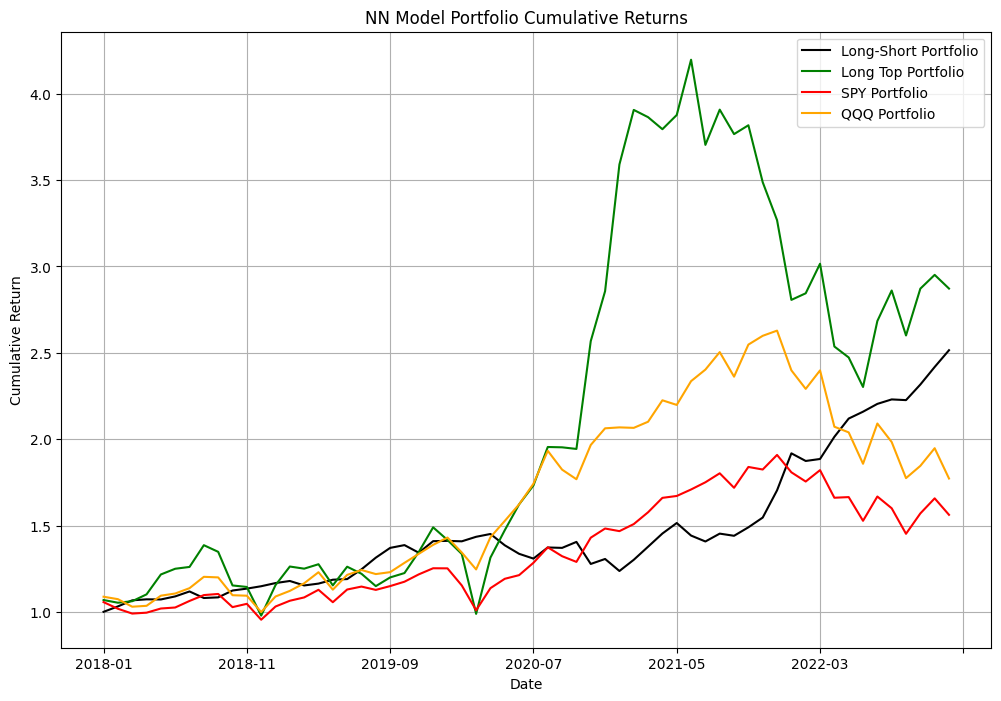

In [74]:
data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)

features = data_for_backtest.drop(columns=['year_month', 
                                        'CUSIP', 
                                        'month_ret', 
                                        'month_exret', 
                                        'rank'])
nnmodel.eval()
    
with torch.no_grad():
    outputs = nnmodel(torch.tensor(features.values, dtype=torch.float).to(device))
    
outputs = outputs.cpu().numpy()

prob_0 = outputs[:, 0]
prob_1 = outputs[:, 1]
prob_2 = outputs[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
bt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)
bt['long_short'] = bt['top_ptf_ret'] - bt['bot_ptf_ret']

# Get Market Return (SPY and QQQ)
mkt = pd.read_csv('SPY_and_QQQ.csv')
mkt = mkt[['Ticker', 'YYYYMM', 'MthRet']]\
    .rename(columns={'YYYYMM': 'year_month'})
    
mkt['year_month'] = mkt['year_month'].astype(str)
mkt['year_month'] = mkt['year_month'].apply(lambda x: x[:4] + '-' + x[4:])
mkt.set_index('year_month', inplace=True)

spy = mkt[mkt['Ticker'] == 'SPY'].copy().rename(columns={'MthRet': 'spy_ret'}).drop(columns=['Ticker'])
qqq = mkt[mkt['Ticker'] == 'QQQ'].copy().rename(columns={'MthRet': 'qqq_ret'}).drop(columns=['Ticker'])

bt['spy_ret'] = spy['spy_ret']
bt['qqq_ret'] = qqq['qqq_ret']

# Calculate Cumulative Long Only and Long/Short Portfolio Return
bt['long_short_cum'] = (bt['long_short'] + 1).cumprod()
bt['long_top_cum'] = (bt['toptop_ptf_ret'] + 1).cumprod()

# Calculate Cumulative SPY and QQQ Return
bt['spy_cum'] = (bt['spy_ret'] + 1).cumprod()
bt['qqq_cum'] = (bt['qqq_ret'] + 1).cumprod()

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot each cumulative return series with specified colors and labels
bt['long_short_cum'].plot(label='Long-Short Portfolio', color='black')
bt['long_top_cum'].plot(label='Long Top Portfolio', color='green')
bt['spy_cum'].plot(label='SPY Portfolio', color='red')
bt['qqq_cum'].plot(label='QQQ Portfolio', color='orange')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('NN Model Portfolio Cumulative Returns')

# Add legend
plt.legend()

# Add grid lines
plt.grid(True)

# Show the plot
plt.show()

In [75]:
data_for_backtest['top_prob_rank'] = data_for_backtest.groupby('year_month')['prob_2'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)
data_for_backtest['bot_prob_rank'] = data_for_backtest.groupby('year_month')['prob_0'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)
data_for_backtest['tmb_rank'] = data_for_backtest.groupby('year_month')['tmb'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)

quintile_ptf_ret_by_top_prob = data_for_backtest.groupby(['year_month', 'top_prob_rank'])['month_ret'].agg('mean').reset_index()
quintile_ptf_ret_by_bot_prob = data_for_backtest.groupby(['year_month', 'bot_prob_rank'])['month_ret'].agg('mean').reset_index()
quintile_ptf_ret_by_tmb = data_for_backtest.groupby(['year_month', 'tmb_rank'])['month_ret'].agg('mean').reset_index()

display(quintile_ptf_ret_by_top_prob.groupby('top_prob_rank')['month_ret'].agg(['mean', 'std']))
display(quintile_ptf_ret_by_bot_prob.groupby('bot_prob_rank')['month_ret'].agg(['mean', 'std']))
display(quintile_ptf_ret_by_tmb.groupby('tmb_rank')['month_ret'].agg(['mean', 'std']))

,mean,std
top_prob_rank,,
0,0.008363,0.050321
1,0.008612,0.066824
2,0.008917,0.071314
3,0.011223,0.085779
4,0.023247,0.108085


,mean,std
bot_prob_rank,,
0,0.008544,0.049696
1,0.009448,0.064928
2,0.013034,0.072615
3,0.014034,0.082350
4,0.015312,0.114323


,mean,std
tmb_rank,,
0,0.006274,0.091720
1,0.007516,0.067412
2,0.009658,0.065118
3,0.014501,0.072985
4,0.022421,0.078953


In [76]:
high_top_prob_ptf = quintile_ptf_ret_by_top_prob[quintile_ptf_ret_by_top_prob['top_prob_rank'] == 4]
low_top_prob_ptf = quintile_ptf_ret_by_top_prob[quintile_ptf_ret_by_top_prob['top_prob_rank'] == 0]
longshort_top_prob = pd.merge(high_top_prob_ptf, low_top_prob_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_top_prob['lsret'] = longshort_top_prob['month_ret_high'] - longshort_top_prob['month_ret_low']

high_bot_prob_ptf = quintile_ptf_ret_by_bot_prob[quintile_ptf_ret_by_bot_prob['bot_prob_rank'] == 4]
low_bot_prob_ptf = quintile_ptf_ret_by_bot_prob[quintile_ptf_ret_by_bot_prob['bot_prob_rank'] == 0]
longshort_bot_prob = pd.merge(high_bot_prob_ptf, low_bot_prob_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_bot_prob['lsret'] = longshort_bot_prob['month_ret_high'] - longshort_bot_prob['month_ret_low']

high_tmb_ptf = quintile_ptf_ret_by_tmb[quintile_ptf_ret_by_tmb['tmb_rank'] == 4]
low_tmb_ptf = quintile_ptf_ret_by_tmb[quintile_ptf_ret_by_tmb['tmb_rank'] == 0]
longshort_tmb = pd.merge(high_tmb_ptf, low_tmb_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_tmb['lsret'] = longshort_tmb['month_ret_high'] - longshort_tmb['month_ret_low']

print('Long Short (4-0) Portfolio Return Using Top Prob Prediction:')
display(longshort_top_prob['lsret'].agg(['mean', 'std']))

print('Long Short (4-0) Portfolio Return Using Bottom Prob Prediction:')
display(longshort_bot_prob['lsret'].agg(['mean', 'std']))

print('Long Short (4-0) Portfolio Return Using TMB:')
display(longshort_tmb['lsret'].agg(['mean', 'std']))

Long Short (4-0) Portfolio Return Using Top Prob Prediction:


mean    0.014883
std     0.078732
Name: lsret, dtype: float64

Long Short (4-0) Portfolio Return Using Bottom Prob Prediction:


mean    0.006767
std     0.085838
Name: lsret, dtype: float64

Long Short (4-0) Portfolio Return Using TMB:


mean    0.016147
std     0.036599
Name: lsret, dtype: float64

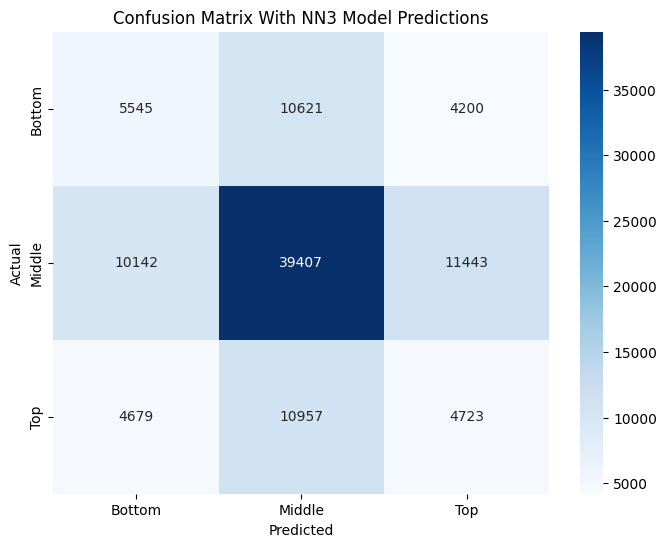

Accuracy rate for Bottom: 27.23%
Accuracy rate for Middle: 64.62%
Accuracy rate for Top: 23.19%


In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
data_for_backtest['rank_pred'] = data_for_backtest['top_preds']-data_for_backtest['bot_preds']+1
# Compute the confusion matrix
cm = confusion_matrix(data_for_backtest['rank'], data_for_backtest['rank_pred'])

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['Bottom', 'Middle', 'Top'], yticklabels=['Bottom', 'Middle', 'Top'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix With NN3 Model Predictions')
plt.show()

# Calculate accuracy rate for each label
accuracy_rate = cm.diagonal() / cm.sum(axis=0)

# Print the accuracy rate for each label
labels = ['Bottom', 'Middle', 'Top']
for i, rate in enumerate(accuracy_rate):

    print(f"Accuracy rate for {labels[i]}: {rate:.2%}")


# Training with XGB Model

In [17]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# 將資料分為訓練集和測試集
features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
labels = data_for_model['rank']
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=42)

# 將標籤編碼為0, 1, 2
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

def Get_XGB_Loss(**kwargs):
    # 建立和訓練模型
    model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, seed=42, **kwargs)
    model.fit(train_features, train_labels_encoded)

    # 預測概率
    train_preds = model.predict_proba(train_features)
    test_preds = model.predict_proba(test_features)


    # 計算訓練集和測試集的對數損失
    train_loss = log_loss(train_labels_encoded, train_preds)
    test_loss = log_loss(test_labels_encoded, test_preds)

    return train_loss, test_loss

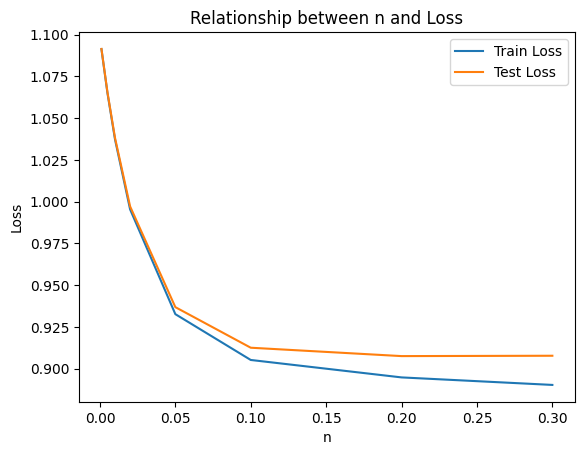

In [5]:
n_space = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
train_losses = []
test_losses = []

for n in n_space:
    train_loss, test_loss = Get_XGB_Loss(max_depth=6, colsample_bytree=0.8, subsample=0.3, n_estimators=25, learning_rate=n, n_jobs=-1)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

plt.plot(n_space, train_losses, label='Train Loss')
plt.plot(n_space, test_losses, label='Test Loss')
plt.xlabel('n')
plt.ylabel('Loss')
plt.title('Relationship between n and Loss')
plt.legend()
plt.show()
    

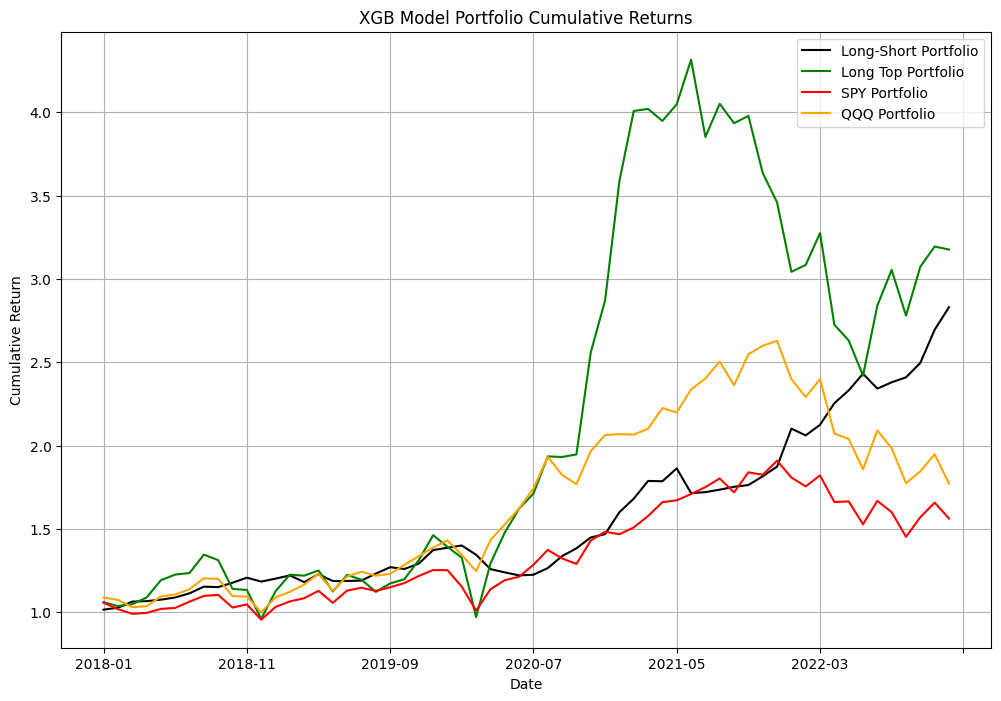

In [81]:
train_features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
train_labels = data_for_model['rank']

data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)
test_features = data_for_backtest.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
test_labels = data_for_backtest['rank']

model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, seed=42, 
                          max_depth=6, colsample_bytree=0.8, subsample=0.3, 
                          n_estimators=25, learning_rate=0.1, n_jobs=-1)

model.fit(train_features, train_labels)

preds = model.predict_proba(test_features)

prob_0 = preds[:, 0]
prob_1 = preds[:, 1]
prob_2 = preds[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
bt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)
bt['long_short'] = bt['top_ptf_ret'] - bt['bot_ptf_ret']

# Get Market Return (SPY and QQQ)
mkt = pd.read_csv('SPY_and_QQQ.csv')
mkt = mkt[['Ticker', 'YYYYMM', 'MthRet']]\
    .rename(columns={'YYYYMM': 'year_month'})
    
mkt['year_month'] = mkt['year_month'].astype(str)
mkt['year_month'] = mkt['year_month'].apply(lambda x: x[:4] + '-' + x[4:])
mkt.set_index('year_month', inplace=True)

spy = mkt[mkt['Ticker'] == 'SPY'].copy().rename(columns={'MthRet': 'spy_ret'}).drop(columns=['Ticker'])
qqq = mkt[mkt['Ticker'] == 'QQQ'].copy().rename(columns={'MthRet': 'qqq_ret'}).drop(columns=['Ticker'])

bt['spy_ret'] = spy['spy_ret']
bt['qqq_ret'] = qqq['qqq_ret']

# Calculate Cumulative Long Only and Long/Short Portfolio Return
bt['long_short_cum'] = (bt['long_short'] + 1).cumprod()
bt['long_top_cum'] = (bt['toptop_ptf_ret'] + 1).cumprod()

# Calculate Cumulative SPY and QQQ Return
bt['spy_cum'] = (bt['spy_ret'] + 1).cumprod()
bt['qqq_cum'] = (bt['qqq_ret'] + 1).cumprod()

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot each cumulative return series with specified colors and labels
bt['long_short_cum'].plot(label='Long-Short Portfolio', color='black')
bt['long_top_cum'].plot(label='Long Top Portfolio', color='green')
bt['spy_cum'].plot(label='SPY Portfolio', color='red')
bt['qqq_cum'].plot(label='QQQ Portfolio', color='orange')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('XGB Model Portfolio Cumulative Returns')

# Add legend
plt.legend()

# Add grid lines
plt.grid(True)

# Show the plot
plt.show()

In [82]:
data_for_backtest['top_prob_rank'] = data_for_backtest.groupby('year_month')['prob_2'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)
data_for_backtest['bot_prob_rank'] = data_for_backtest.groupby('year_month')['prob_0'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)
data_for_backtest['tmb_rank'] = data_for_backtest.groupby('year_month')['tmb'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)

quintile_ptf_ret_by_top_prob = data_for_backtest.groupby(['year_month', 'top_prob_rank'])['month_ret'].agg('mean').reset_index()
quintile_ptf_ret_by_bot_prob = data_for_backtest.groupby(['year_month', 'bot_prob_rank'])['month_ret'].agg('mean').reset_index()
quintile_ptf_ret_by_tmb = data_for_backtest.groupby(['year_month', 'tmb_rank'])['month_ret'].agg('mean').reset_index()

display(quintile_ptf_ret_by_top_prob.groupby('top_prob_rank')['month_ret'].agg(['mean', 'std']))
display(quintile_ptf_ret_by_bot_prob.groupby('bot_prob_rank')['month_ret'].agg(['mean', 'std']))
display(quintile_ptf_ret_by_tmb.groupby('tmb_rank')['month_ret'].agg(['mean', 'std']))

,mean,std
top_prob_rank,,
0,0.008053,0.052574
1,0.008791,0.066723
2,0.008874,0.071628
3,0.009652,0.083083
4,0.024991,0.107416


,mean,std
bot_prob_rank,,
0,0.008604,0.052295
1,0.009341,0.063905
2,0.012062,0.071280
3,0.015282,0.084974
4,0.015085,0.110539


,mean,std
tmb_rank,,
0,0.007573,0.084012
1,0.009079,0.070779
2,0.009486,0.068563
3,0.008562,0.069987
4,0.025663,0.081395


In [83]:
high_top_prob_ptf = quintile_ptf_ret_by_top_prob[quintile_ptf_ret_by_top_prob['top_prob_rank'] == 4]
low_top_prob_ptf = quintile_ptf_ret_by_top_prob[quintile_ptf_ret_by_top_prob['top_prob_rank'] == 0]
longshort_top_prob = pd.merge(high_top_prob_ptf, low_top_prob_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_top_prob['lsret'] = longshort_top_prob['month_ret_high'] - longshort_top_prob['month_ret_low']

high_bot_prob_ptf = quintile_ptf_ret_by_bot_prob[quintile_ptf_ret_by_bot_prob['bot_prob_rank'] == 4]
low_bot_prob_ptf = quintile_ptf_ret_by_bot_prob[quintile_ptf_ret_by_bot_prob['bot_prob_rank'] == 0]
longshort_bot_prob = pd.merge(high_bot_prob_ptf, low_bot_prob_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_bot_prob['lsret'] = longshort_bot_prob['month_ret_high'] - longshort_bot_prob['month_ret_low']

high_tmb_ptf = quintile_ptf_ret_by_tmb[quintile_ptf_ret_by_tmb['tmb_rank'] == 4]
low_tmb_ptf = quintile_ptf_ret_by_tmb[quintile_ptf_ret_by_tmb['tmb_rank'] == 0]
longshort_tmb = pd.merge(high_tmb_ptf, low_tmb_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_tmb['lsret'] = longshort_tmb['month_ret_high'] - longshort_tmb['month_ret_low']

print('Long Short (4-0) Portfolio Return Using Top Prob Prediction:')
display(longshort_top_prob['lsret'].agg(['mean', 'std']))

print('Long Short (4-0) Portfolio Return Using Bottom Prob Prediction:')
display(longshort_bot_prob['lsret'].agg(['mean', 'std']))

print('Long Short (4-0) Portfolio Return Using TMB:')
display(longshort_tmb['lsret'].agg(['mean', 'std']))

Long Short (4-0) Portfolio Return Using Top Prob Prediction:


mean    0.016938
std     0.075579
Name: lsret, dtype: float64

Long Short (4-0) Portfolio Return Using Bottom Prob Prediction:


mean    0.006481
std     0.080854
Name: lsret, dtype: float64

Long Short (4-0) Portfolio Return Using TMB:


mean    0.018090
std     0.034696
Name: lsret, dtype: float64

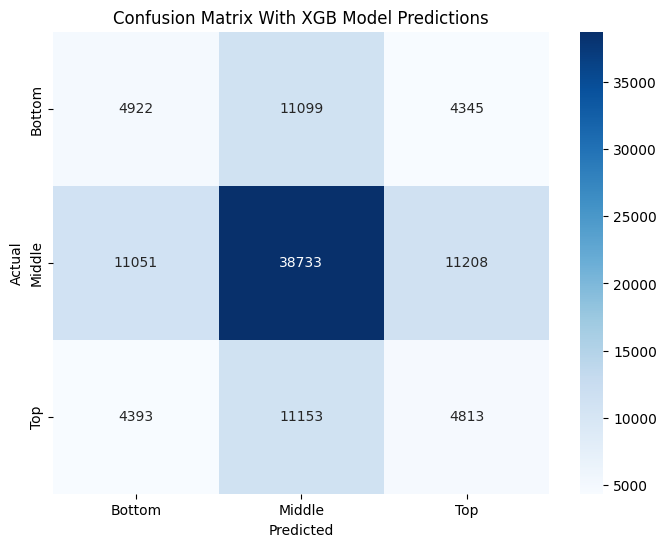

Accuracy rate for Bottom: 24.17%
Accuracy rate for Middle: 63.51%
Accuracy rate for Top: 23.63%


In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
data_for_backtest['rank_pred'] = data_for_backtest['top_preds']-data_for_backtest['bot_preds']+1
# Compute the confusion matrix
cm = confusion_matrix(data_for_backtest['rank'], data_for_backtest['rank_pred'])

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['Bottom', 'Middle', 'Top'], yticklabels=['Bottom', 'Middle', 'Top'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix With XGB Model Predictions')
plt.show()

# Calculate accuracy rate for each label
accuracy_rate = cm.diagonal() / cm.sum(axis=0)

# Print the accuracy rate for each label
labels = ['Bottom', 'Middle', 'Top']
for i, rate in enumerate(accuracy_rate):

    print(f"Accuracy rate for {labels[i]}: {rate:.2%}")

# Training with LGBM Model

In [68]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# 將資料分為訓練集和測試集
features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
labels = data_for_model['rank']
train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.3, random_state=42)

# 將標籤編碼為0, 1, 2
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_labels)
test_labels_encoded = le.transform(test_labels)

def Get_LGBM_Loss(**kwargs):
    # 建立和訓練模型
    model = lgb.LGBMClassifier(objective='multiclass', num_class=3, random_state=42, n_jobs=-1, verbose = -1, **kwargs)
    model.fit(train_features, train_labels_encoded)

    # 預測概率
    train_preds = model.predict_proba(train_features)
    test_preds = model.predict_proba(test_features)


    # 計算訓練集和測試集的對數損失
    train_loss = log_loss(train_labels_encoded, train_preds)
    test_loss = log_loss(test_labels_encoded, test_preds)

    return train_loss, test_loss

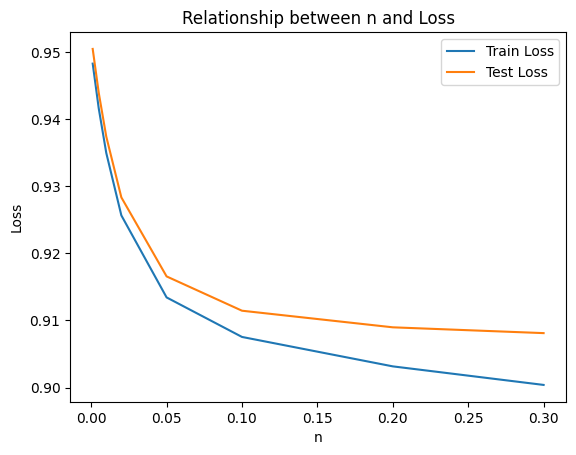

In [69]:
n_space = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]
train_losses = []
test_losses = []

for n in n_space:
    train_loss, test_loss = Get_LGBM_Loss(max_depth=5, num_leaves = 13, 
                                         n_estimators = 30, colsample_bytree = 0.5,
                                         learning_rate = n)
    train_losses.append(train_loss)
    test_losses.append(test_loss)

plt.plot(n_space, train_losses, label='Train Loss')
plt.plot(n_space, test_losses, label='Test Loss')
plt.xlabel('n')
plt.ylabel('Loss')
plt.title('Relationship between n and Loss')
plt.legend()
plt.show()

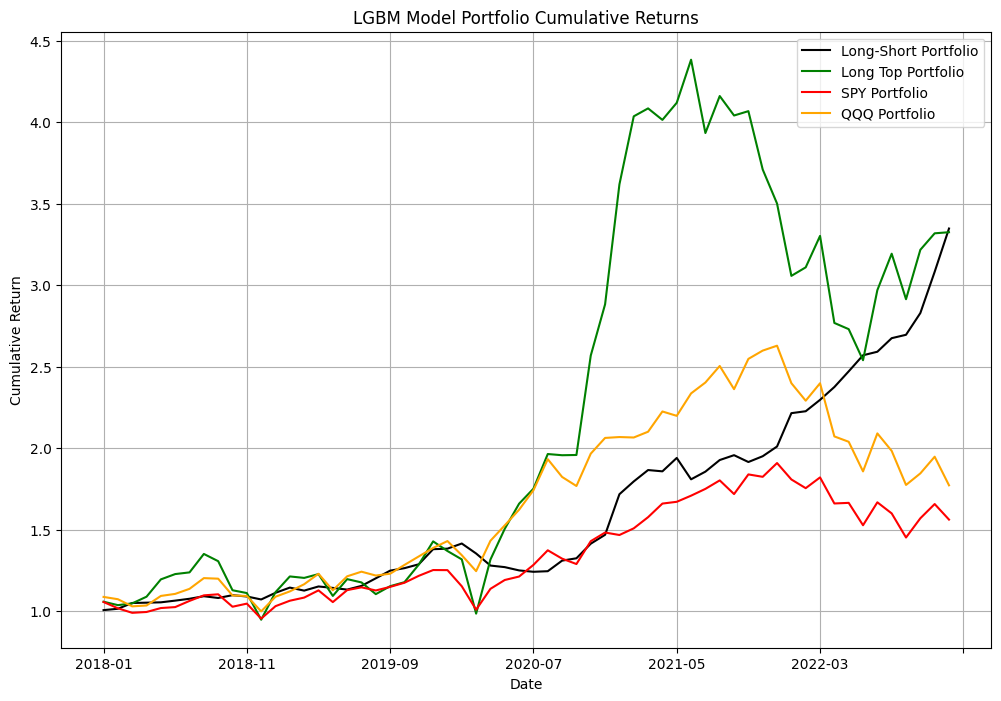

In [85]:
train_features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
train_labels = data_for_model['rank']

data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)
test_features = data_for_backtest.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
test_labels = data_for_backtest['rank']

model = lgb.LGBMClassifier(objective='multiclass', num_class=3, random_state=42, n_jobs=-1, verbose = -1, 
                           max_depth=5, num_leaves = 13, 
                            n_estimators = 30, colsample_bytree = 0.5,
                            learning_rate = 0.1)

model.fit(train_features, train_labels)

preds = model.predict_proba(test_features)

prob_0 = preds[:, 0]
prob_1 = preds[:, 1]
prob_2 = preds[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
bt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)
bt['long_short'] = bt['top_ptf_ret'] - bt['bot_ptf_ret']

# Get Market Return (SPY and QQQ)
mkt = pd.read_csv('SPY_and_QQQ.csv')
mkt = mkt[['Ticker', 'YYYYMM', 'MthRet']]\
    .rename(columns={'YYYYMM': 'year_month'})
    
mkt['year_month'] = mkt['year_month'].astype(str)
mkt['year_month'] = mkt['year_month'].apply(lambda x: x[:4] + '-' + x[4:])
mkt.set_index('year_month', inplace=True)

spy = mkt[mkt['Ticker'] == 'SPY'].copy().rename(columns={'MthRet': 'spy_ret'}).drop(columns=['Ticker'])
qqq = mkt[mkt['Ticker'] == 'QQQ'].copy().rename(columns={'MthRet': 'qqq_ret'}).drop(columns=['Ticker'])

bt['spy_ret'] = spy['spy_ret']
bt['qqq_ret'] = qqq['qqq_ret']

# Calculate Cumulative Long Only and Long/Short Portfolio Return
bt['long_short_cum'] = (bt['long_short'] + 1).cumprod()
bt['long_top_cum'] = (bt['toptop_ptf_ret'] + 1).cumprod()

# Calculate Cumulative SPY and QQQ Return
bt['spy_cum'] = (bt['spy_ret'] + 1).cumprod()
bt['qqq_cum'] = (bt['qqq_ret'] + 1).cumprod()

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot each cumulative return series with specified colors and labels
bt['long_short_cum'].plot(label='Long-Short Portfolio', color='black')
bt['long_top_cum'].plot(label='Long Top Portfolio', color='green')
bt['spy_cum'].plot(label='SPY Portfolio', color='red')
bt['qqq_cum'].plot(label='QQQ Portfolio', color='orange')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('LGBM Model Portfolio Cumulative Returns')

# Add legend
plt.legend()

# Add grid lines
plt.grid(True)

# Show the plot
plt.show()

In [86]:
data_for_backtest['top_prob_rank'] = data_for_backtest.groupby('year_month')['prob_2'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)
data_for_backtest['bot_prob_rank'] = data_for_backtest.groupby('year_month')['prob_0'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)
data_for_backtest['tmb_rank'] = data_for_backtest.groupby('year_month')['tmb'].apply(lambda x: pd.qcut(x, q=5, labels=[i for i in range(5)])).reset_index(drop=True)

quintile_ptf_ret_by_top_prob = data_for_backtest.groupby(['year_month', 'top_prob_rank'])['month_ret'].agg('mean').reset_index()
quintile_ptf_ret_by_bot_prob = data_for_backtest.groupby(['year_month', 'bot_prob_rank'])['month_ret'].agg('mean').reset_index()
quintile_ptf_ret_by_tmb = data_for_backtest.groupby(['year_month', 'tmb_rank'])['month_ret'].agg('mean').reset_index()

display(quintile_ptf_ret_by_top_prob.groupby('top_prob_rank')['month_ret'].agg(['mean', 'std']))
display(quintile_ptf_ret_by_bot_prob.groupby('bot_prob_rank')['month_ret'].agg(['mean', 'std']))
display(quintile_ptf_ret_by_tmb.groupby('tmb_rank')['month_ret'].agg(['mean', 'std']))

,mean,std
top_prob_rank,,
0,0.007930,0.052578
1,0.007688,0.067004
2,0.009715,0.072064
3,0.009414,0.082840
4,0.025615,0.106539


,mean,std
bot_prob_rank,,
0,0.008044,0.053141
1,0.009548,0.063957
2,0.011730,0.071787
3,0.015291,0.083405
4,0.015760,0.111344


,mean,std
tmb_rank,,
0,0.006070,0.082154
1,0.009153,0.070468
2,0.007683,0.067850
3,0.010376,0.070162
4,0.027080,0.085056


In [87]:
high_top_prob_ptf = quintile_ptf_ret_by_top_prob[quintile_ptf_ret_by_top_prob['top_prob_rank'] == 4]
low_top_prob_ptf = quintile_ptf_ret_by_top_prob[quintile_ptf_ret_by_top_prob['top_prob_rank'] == 0]
longshort_top_prob = pd.merge(high_top_prob_ptf, low_top_prob_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_top_prob['lsret'] = longshort_top_prob['month_ret_high'] - longshort_top_prob['month_ret_low']

high_bot_prob_ptf = quintile_ptf_ret_by_bot_prob[quintile_ptf_ret_by_bot_prob['bot_prob_rank'] == 4]
low_bot_prob_ptf = quintile_ptf_ret_by_bot_prob[quintile_ptf_ret_by_bot_prob['bot_prob_rank'] == 0]
longshort_bot_prob = pd.merge(high_bot_prob_ptf, low_bot_prob_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_bot_prob['lsret'] = longshort_bot_prob['month_ret_high'] - longshort_bot_prob['month_ret_low']

high_tmb_ptf = quintile_ptf_ret_by_tmb[quintile_ptf_ret_by_tmb['tmb_rank'] == 4]
low_tmb_ptf = quintile_ptf_ret_by_tmb[quintile_ptf_ret_by_tmb['tmb_rank'] == 0]
longshort_tmb = pd.merge(high_tmb_ptf, low_tmb_ptf, on='year_month', suffixes=('_high', '_low'))
longshort_tmb['lsret'] = longshort_tmb['month_ret_high'] - longshort_tmb['month_ret_low']

print('Long Short (4-0) Portfolio Return Using Top Prob Prediction:')
display(longshort_top_prob['lsret'].agg(['mean', 'std']))

print('Long Short (4-0) Portfolio Return Using Bottom Prob Prediction:')
display(longshort_bot_prob['lsret'].agg(['mean', 'std']))

print('Long Short (4-0) Portfolio Return Using TMB:')
display(longshort_tmb['lsret'].agg(['mean', 'std']))

Long Short (4-0) Portfolio Return Using Top Prob Prediction:


mean    0.017685
std     0.075528
Name: lsret, dtype: float64

Long Short (4-0) Portfolio Return Using Bottom Prob Prediction:


mean    0.007715
std     0.080827
Name: lsret, dtype: float64

Long Short (4-0) Portfolio Return Using TMB:


mean    0.021009
std     0.036986
Name: lsret, dtype: float64

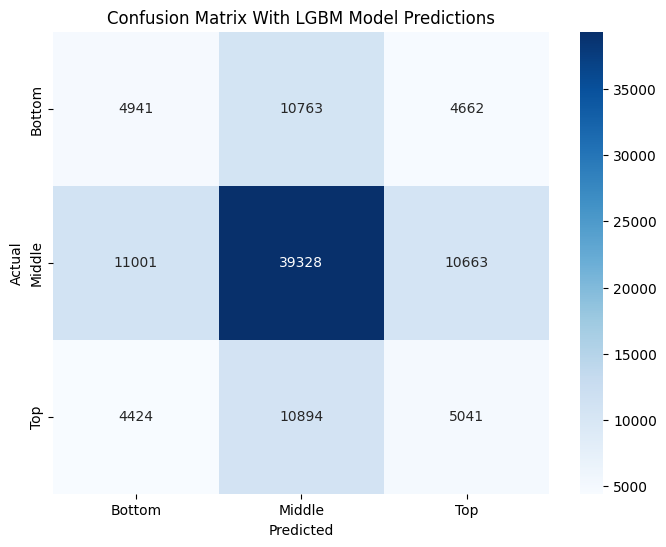

Accuracy rate for Bottom: 24.26%
Accuracy rate for Middle: 64.49%
Accuracy rate for Top: 24.75%


In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
data_for_backtest['rank_pred'] = data_for_backtest['top_preds']-data_for_backtest['bot_preds']+1
# Compute the confusion matrix
cm = confusion_matrix(data_for_backtest['rank'], data_for_backtest['rank_pred'])

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=['Bottom', 'Middle', 'Top'], yticklabels=['Bottom', 'Middle', 'Top'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix With LGBM Model Predictions')
plt.show()

# Calculate accuracy rate for each label
accuracy_rate = cm.diagonal() / cm.sum(axis=0)

# Print the accuracy rate for each label
labels = ['Bottom', 'Middle', 'Top']
for i, rate in enumerate(accuracy_rate):

    print(f"Accuracy rate for {labels[i]}: {rate:.2%}")

# Model Comparism

Text(0.5, 1.0, 'Long Top Portfolio Cumulative Returns Comparison')

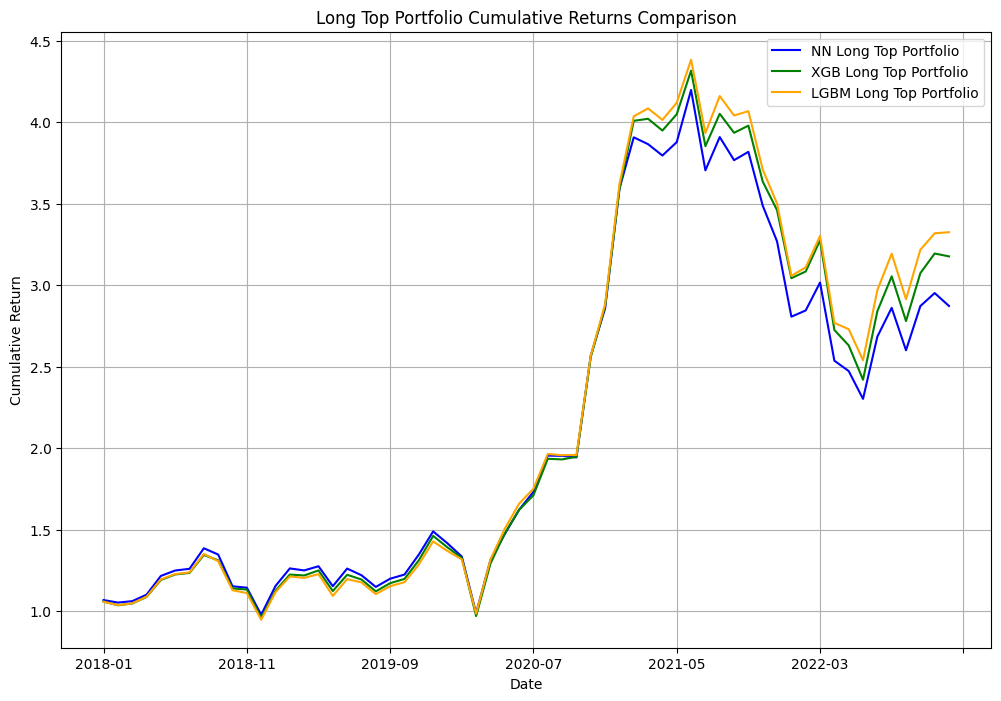

In [44]:
data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)

features = data_for_backtest.drop(columns=['year_month', 
                                        'CUSIP', 
                                        'month_ret', 
                                        'month_exret', 
                                        'rank'])
nnmodel.eval()
    
with torch.no_grad():
    outputs = nnmodel(torch.tensor(features.values, dtype=torch.float).to(device))
    
outputs = outputs.cpu().numpy()

prob_0 = outputs[:, 0]
prob_1 = outputs[:, 1]
prob_2 = outputs[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
nnbt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)

# Calculate Cumulative Long Only and Long/Short Portfolio Return
nnbt['long_top_cum'] = (nnbt['toptop_ptf_ret'] + 1).cumprod()

############################################

train_features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
train_labels = data_for_model['rank']

data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)
test_features = data_for_backtest.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
test_labels = data_for_backtest['rank']

model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, seed=42, 
                          max_depth=6, colsample_bytree=0.8, subsample=0.3, 
                          n_estimators=25, learning_rate=0.1, n_jobs=-1)

model.fit(train_features, train_labels)

preds = model.predict_proba(test_features)

prob_0 = preds[:, 0]
prob_1 = preds[:, 1]
prob_2 = preds[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
xgbbt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)

# Calculate Cumulative Long Only and Long/Short Portfolio Return
xgbbt['long_top_cum'] = (xgbbt['toptop_ptf_ret'] + 1).cumprod()

############################################

train_features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
train_labels = data_for_model['rank']

data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)
test_features = data_for_backtest.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
test_labels = data_for_backtest['rank']

model = lgb.LGBMClassifier(objective='multiclass', num_class=3, random_state=42, n_jobs=-1, verbose = -1, 
                           max_depth=5, num_leaves = 13, 
                            n_estimators = 30, colsample_bytree = 0.5,
                            learning_rate = 0.1)

model.fit(train_features, train_labels)

preds = model.predict_proba(test_features)

prob_0 = preds[:, 0]
prob_1 = preds[:, 1]
prob_2 = preds[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
lgbmbt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)

# Calculate Cumulative Long Only and Long/Short Portfolio Return
lgbmbt['long_top_cum'] = (lgbmbt['toptop_ptf_ret'] + 1).cumprod()

############################################

# Set the figure size
plt.figure(figsize=(12, 8))
nnbt['long_top_cum'].plot(label='NN Long Top Portfolio', color='blue')
xgbbt['long_top_cum'].plot(label='XGB Long Top Portfolio', color='green')
lgbmbt['long_top_cum'].plot(label='LGBM Long Top Portfolio', color='orange')

# Add labels and title
plt.legend()
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Long Top Portfolio Cumulative Returns Comparison')

Text(0.5, 1.0, 'Long Short Portfolio Cumulative Returns Comparison')

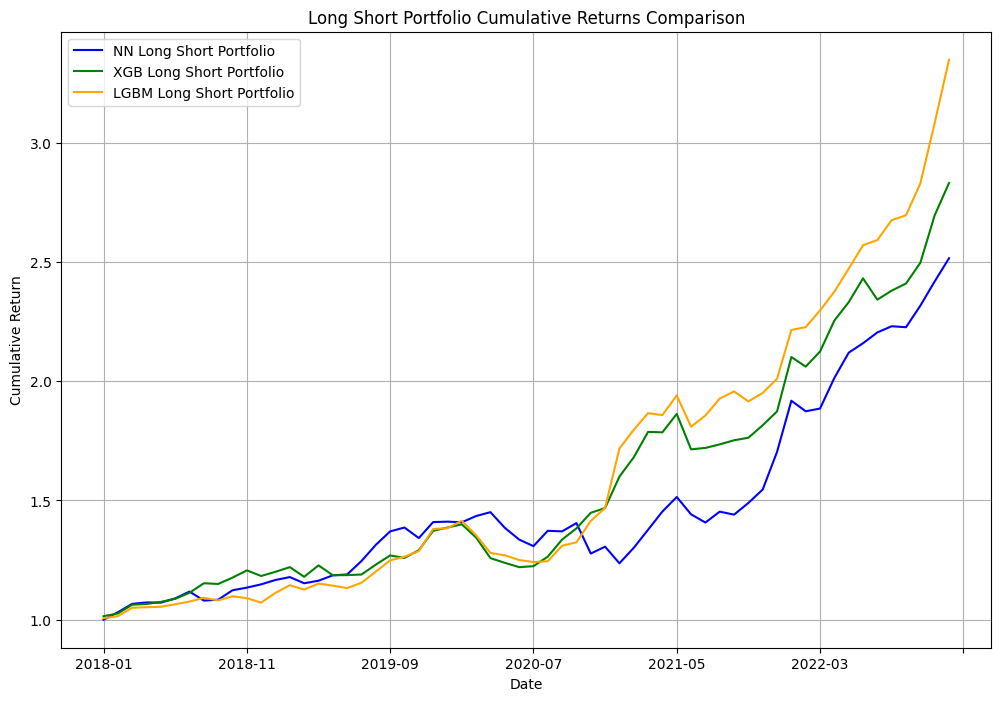

In [45]:
data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)

features = data_for_backtest.drop(columns=['year_month', 
                                        'CUSIP', 
                                        'month_ret', 
                                        'month_exret', 
                                        'rank'])
nnmodel.eval()
    
with torch.no_grad():
    outputs = nnmodel(torch.tensor(features.values, dtype=torch.float).to(device))
    
outputs = outputs.cpu().numpy()

prob_0 = outputs[:, 0]
prob_1 = outputs[:, 1]
prob_2 = outputs[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
nnbt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)

# Calculate Cumulative Long Only and Long/Short Portfolio Return
nnbt['lsret'] = nnbt['top_ptf_ret'] - nnbt['bot_ptf_ret']
nnbt['long_short_cum'] = (nnbt['lsret'] + 1).cumprod()

############################################

train_features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
train_labels = data_for_model['rank']

data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)
test_features = data_for_backtest.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
test_labels = data_for_backtest['rank']

model = xgb.XGBClassifier(objective='multi:softprob', num_class=3, seed=42, 
                          max_depth=6, colsample_bytree=0.8, subsample=0.3, 
                          n_estimators=25, learning_rate=0.1, n_jobs=-1)

model.fit(train_features, train_labels)

preds = model.predict_proba(test_features)

prob_0 = preds[:, 0]
prob_1 = preds[:, 1]
prob_2 = preds[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
xgbbt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)

# Calculate Cumulative Long Only and Long/Short Portfolio Return
xgbbt['lsret'] = xgbbt['top_ptf_ret'] - xgbbt['bot_ptf_ret']
xgbbt['long_short_cum'] = (xgbbt['lsret'] + 1).cumprod()

############################################

train_features = data_for_model.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
train_labels = data_for_model['rank']

data_for_backtest = data[data['year_month']>='2018'].copy().reset_index(drop = True)
test_features = data_for_backtest.drop(columns=['year_month', 'CUSIP', 'month_ret', 'month_exret', 'rank'])
test_labels = data_for_backtest['rank']

model = lgb.LGBMClassifier(objective='multiclass', num_class=3, random_state=42, n_jobs=-1, verbose = -1, 
                           max_depth=5, num_leaves = 13, 
                            n_estimators = 30, colsample_bytree = 0.5,
                            learning_rate = 0.1)

model.fit(train_features, train_labels)

preds = model.predict_proba(test_features)

prob_0 = preds[:, 0]
prob_1 = preds[:, 1]
prob_2 = preds[:, 2]

data_for_backtest['prob_0'] = prob_0 # Bottom
data_for_backtest['prob_1'] = prob_1 # Middle
data_for_backtest['prob_2'] = prob_2 # Top


data_for_backtest.sort_values(['year_month', 'CUSIP'], ascending=[True, True], inplace=True)
data_for_backtest['tmb'] = data_for_backtest['prob_2'] - data_for_backtest['prob_0']

# # 每個月份中預測概率最高的20%的樣本分類為1
data_for_backtest['top_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x >= x.quantile(0.8)).astype(int)
data_for_backtest['bot_preds'] = data_for_backtest.groupby('year_month')['tmb'].transform(lambda x: x <= x.quantile(0.2)).astype(int)
data_for_backtest['toptop'] = data_for_backtest.groupby('year_month')['prob_2'].transform(lambda x: x >= x.quantile(0.8)).astype(int)

toptop =  data_for_backtest[data_for_backtest['toptop'] == 1].copy()
toptop_ptf_ret = toptop.groupby(['year_month'])['month_ret'].agg('mean').rename('toptop_ptf_ret')
toptop_ptf_ret = pd.DataFrame(toptop_ptf_ret)

# Get Top and Bottom Flag Prediction
top = data_for_backtest[data_for_backtest['top_preds'] == 1].copy()
top_ptf_ret = top.groupby(['year_month'])['month_ret'].agg('mean').rename('top_ptf_ret')
top_ptf_ret = pd.DataFrame(top_ptf_ret)

bot = data_for_backtest[data_for_backtest['bot_preds'] == 1].copy()
bot_ptf_ret = bot.groupby(['year_month'])['month_ret'].agg('mean').rename('bot_ptf_ret')
bot_ptf_ret = pd.DataFrame(bot_ptf_ret)

# Merge Top and Bottom Flag Prediction
lgbmbt = pd.concat([top_ptf_ret, bot_ptf_ret, toptop_ptf_ret], axis=1)

# Calculate Cumulative Long Only and Long/Short Portfolio Return
lgbmbt['lsret'] = lgbmbt['top_ptf_ret'] - lgbmbt['bot_ptf_ret']
lgbmbt['long_short_cum'] = (lgbmbt['lsret'] + 1).cumprod()

############################################

# Set the figure size
plt.figure(figsize=(12, 8))
nnbt['long_short_cum'].plot(label='NN Long Short Portfolio', color='blue')
xgbbt['long_short_cum'].plot(label='XGB Long Short Portfolio', color='green')
lgbmbt['long_short_cum'].plot(label='LGBM Long Short Portfolio', color='orange')

# Add labels and title
plt.legend()
plt.grid(True)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Long Short Portfolio Cumulative Returns Comparison')